In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
all_datasets = ["esc50", "domestic"]
all_total_classes = [ 50, 34]
all_datasets_name = ["ESC-50", "Domestic Environment"]
metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]
INDEX = 0

DATASET = all_datasets[INDEX]
TOTAL_CLASSES = all_total_classes[INDEX]
DATASET_NAME = all_datasets_name[INDEX]

df_original = pd.read_csv(f"../results/{DATASET}_results_new.csv")
print(df_original.dtypes)
# 只保留特定的 classifier
df = df_original[df_original["rejection_method"].isin(["global_threshold", "class_threshold", "class_percentile"])].copy()

df["known %"] = (df["num_known"]) / (TOTAL_CLASSES)


df_mean = (
    df.groupby([
        "embedding",
        "rejection_method",
        "classifier",
        "num_known",
        "num_unknown",
        "known %"
    ])
    .mean(numeric_only=True)
    .reset_index()
)

for m in metrics:
    df_mean[m] = df_mean[m] * 100
    
print(df_mean.dtypes)

dataset                 str
embedding               str
rejection_method        str
classifier              str
num_known             int64
num_unknown           int64
seed                  int64
threshold               str
ACC_known           float64
ACC_unknown         float64
AUROC               float64
OSCR                float64
dtype: object
embedding               str
rejection_method        str
classifier              str
num_known             int64
num_unknown           int64
known %             float64
seed                float64
ACC_known           float64
ACC_unknown         float64
AUROC               float64
OSCR                float64
dtype: object


embedding               str
rejection_method        str
classifier              str
num_known             int64
num_unknown           int64
known %             float64
seed                float64
ACC_known           float64
ACC_unknown         float64
AUROC               float64
OSCR                float64
dtype: object
(30, 11)
   embedding  rejection_method classifier  num_known  num_unknown  known %  \
90      clap  global_threshold     cosine         10           40      0.2   
91      clap  global_threshold     cosine         15           35      0.3   
92      clap  global_threshold     cosine         20           30      0.4   
93      clap  global_threshold     cosine         30           20      0.6   
94      clap  global_threshold     cosine         40           10      0.8   

    seed  ACC_known  ACC_unknown      AUROC       OSCR  
90   0.0  98.750000    85.937500  99.093750  98.062500  
91   0.0  95.833333    84.285714  97.639881  94.915179  
92   0.0  96.875000    82.083

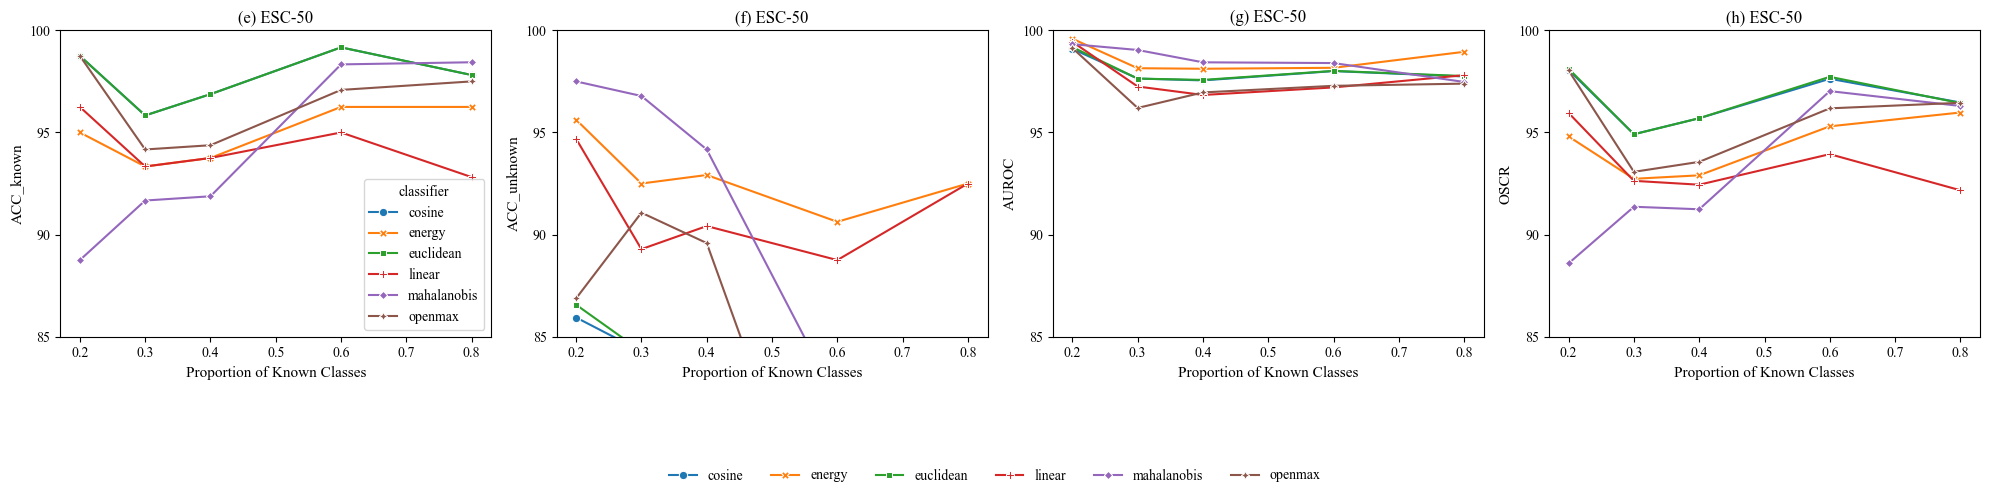

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "global_threshold")
]
print(clap_class_df.dtypes)
print(clap_class_df.shape)
print(clap_class_df.head())

# 全局字体
plt.rcParams["font.family"] = "Times New Roman"

# 创建 1x4 子图
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

# y轴刻度
yticks = np.arange(85, 101, 5)
"(a)", "(b)", "(c)", "(d)",
letters = [ "(e)", "(f)", "(g)", "(h)"]

for i, m in enumerate(metrics):

    sns.lineplot(
        data=clap_class_df,
        x="known %",
        y=m,
        hue="classifier",
        style="classifier",
        markers=True,
        dashes=False,
        ax=axes[i],
        legend=(i == 0)
    )

    # 子图标题
    axes[i].set_title(f"{letters[i]} {DATASET_NAME}", fontsize=12)

    # x轴
    axes[i].set_xlabel("Proportion of Known Classes", fontsize=11)

    # 统一y轴范围
    axes[i].set_ylim(85, 100)

    # 设置y刻度
    axes[i].set_yticks(yticks)

    # 只显示每10的label
    axes[i].set_yticklabels(
        [str(y) if y % 5 == 0 else "" for y in yticks]
    )

    # 只有第一个子图显示y label
    if i == 0:
        axes[i].set_ylabel(f"{m}", fontsize=11)
    else:
        axes[i].set_ylabel(f"{m}", fontsize=11)

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.25),
    frameon=False
)

plt.tight_layout()
plt.savefig(f"{DATASET_NAME}_clap_globalthreshold.png", dpi=300, bbox_inches="tight")
plt.show()

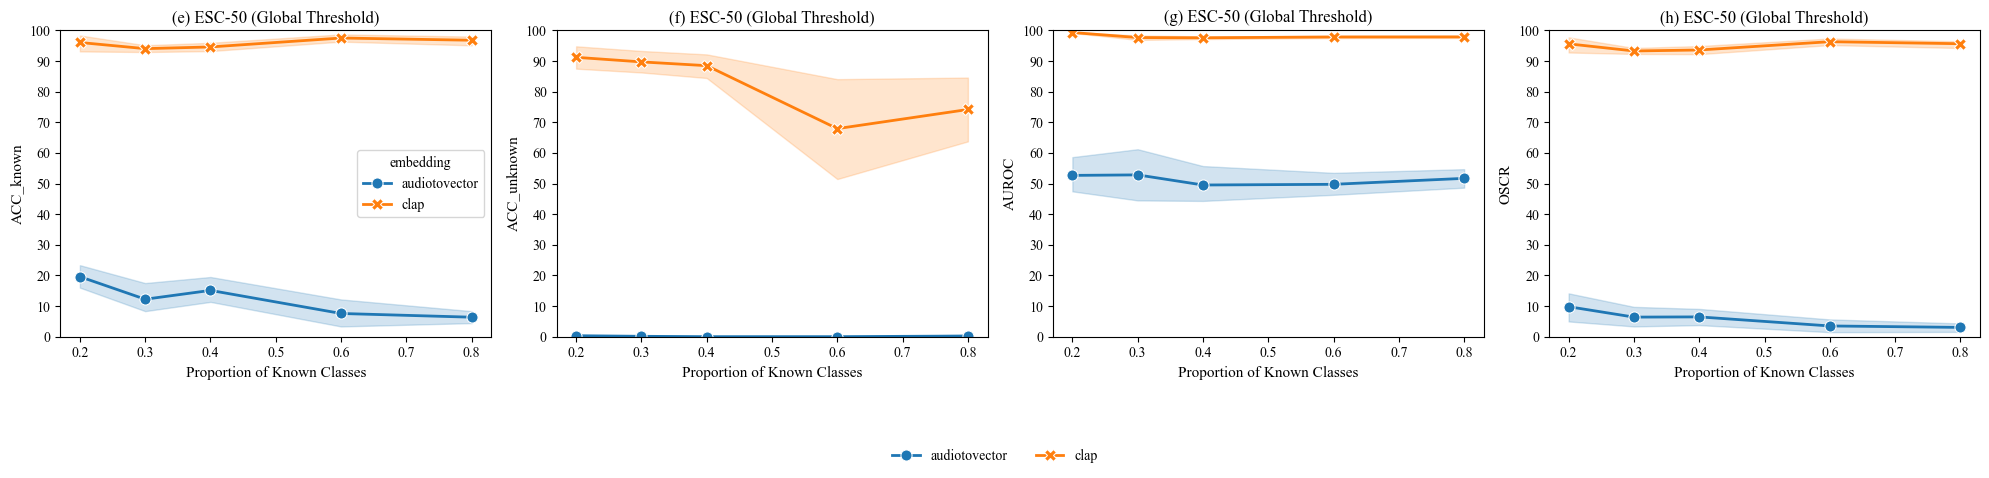

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

embedding_df = df_mean[
    df_mean["rejection_method"] == "global_threshold"
]

# 全局字体
plt.rcParams["font.family"] = "Times New Roman"

# 创建 1x4 子图
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

# y轴刻度
yticks = np.arange(0, 101, 10)

letters = ["(a)", "(b)", "(c)", "(d)"]

letters = ["(e)", "(f)", "(g)", "(h)"]

for i, m in enumerate(metrics):

    sns.lineplot(
        data=embedding_df,
        x="known %",
        y=m,
        hue="embedding",
        style="embedding",
        markers=True,
        dashes=False,
        markersize=8,
        linewidth=2,
        ax=axes[i],
        legend=(i == 0)
    )

    # 子图标题
    axes[i].set_title(f"{letters[i]} {DATASET_NAME} (Global Threshold)", fontsize=12)

    # x轴
    axes[i].set_xlabel("Proportion of Known Classes", fontsize=11)

    # y轴
    axes[i].set_ylabel(f"{m}", fontsize=11)

    # 统一y范围
    axes[i].set_ylim(0, 100)

    # y刻度
    axes[i].set_yticks(yticks)

    axes[i].set_yticklabels(
        [str(y) if y % 5 == 0 else "" for y in yticks]
    )

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.2),
    frameon=False
)

plt.tight_layout()

plt.savefig(
    f"{DATASET_NAME}_embedding_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

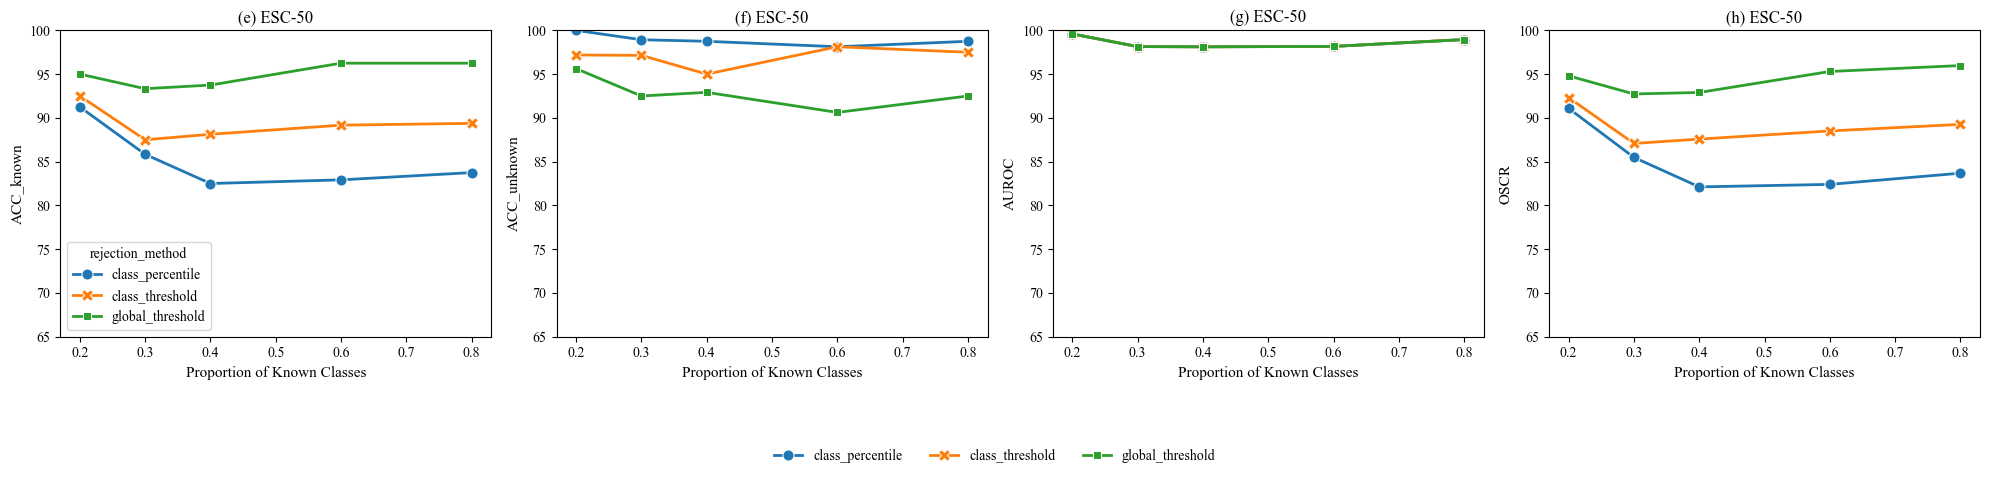

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

threshold_df = df_mean[
    (df_mean["embedding"] == "clap") &     # 固定embedding
    (df_mean["classifier"] == "energy")    # 固定classifier（推荐）
]

plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

yticks = np.arange(65, 101, 5)

letters = ["(a)", "(b)", "(c)", "(d)"]
letters = ["(e)", "(f)", "(g)", "(h)"]

for i, m in enumerate(metrics):

    sns.lineplot(
        data=threshold_df,
        x="known %",
        y=m,
        hue="rejection_method",
        style="rejection_method",
        markers=True,
        dashes=False,
        linewidth=2,
        markersize=8,
        ax=axes[i],
        legend=(i == 0)
    )

    axes[i].set_title(f"{letters[i]} {DATASET_NAME}", fontsize=12)

    axes[i].set_xlabel("Proportion of Known Classes", fontsize=11)
    axes[i].set_ylabel(f"{m}", fontsize=11)

    axes[i].set_ylim(65, 100)
    axes[i].set_yticks(yticks)

    axes[i].set_yticklabels(
        [str(y) if y % 5 == 0 else "" for y in yticks]
    )

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.2),
    frameon=False
)

plt.tight_layout()

plt.savefig(
    f"{DATASET_NAME}_threshold_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()